In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import cufflinks as cf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
df=pd.read_csv('IPL.csv')
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [8]:
print(f"Your rows are {df.shape[0]} and your columns are {df.shape[1]}")

Your rows are 74 and your columns are 20


In [9]:
#Which Team won the most matches
match_wins=df['match_winner'].value_counts()

Text(0, 0.5, 'Teams')

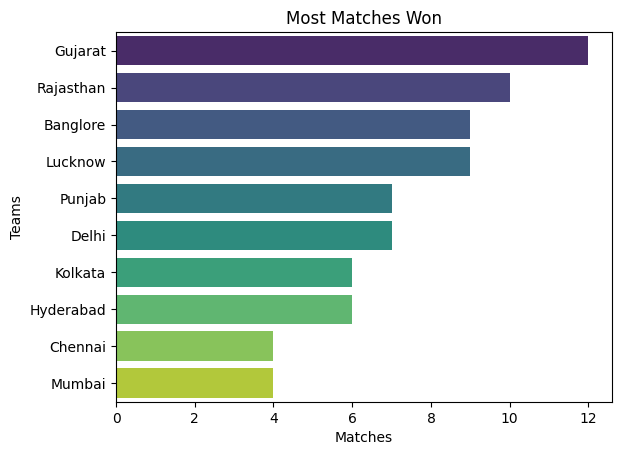

In [10]:
sns.barplot(y=match_wins.index,x=match_wins.values,palette='viridis')
plt.title('Most Matches Won')
plt.xlabel('Matches')
plt.ylabel('Teams')

Text(0.5, 1.0, 'Toss Decision Trends')

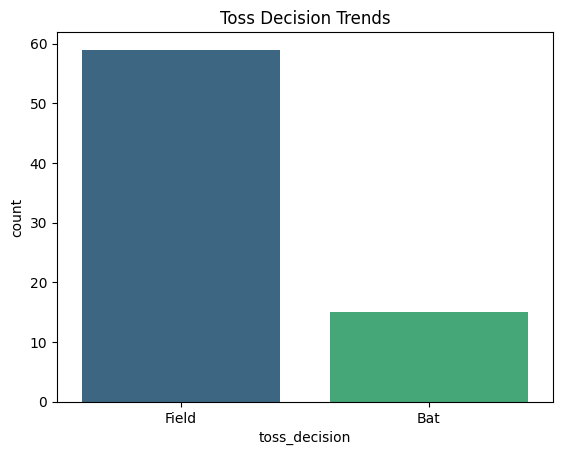

In [14]:
#Toss Decision Trends
sns.countplot(x='toss_decision',data=df,palette='viridis')
plt.title('Toss Decision Trends')

In [12]:
#Toss Winner vs Match Winner
counts=df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage=(counts*100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

<Axes: xlabel='won_by', ylabel='count'>

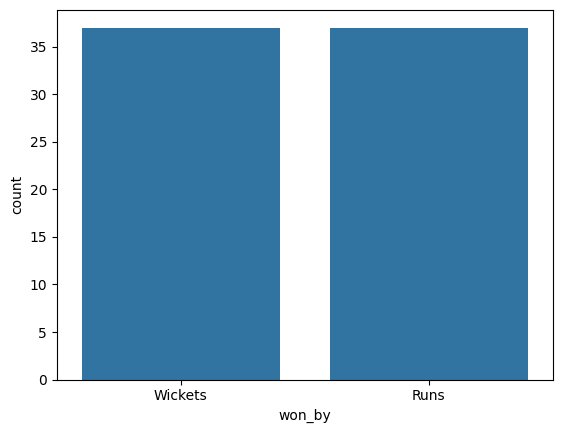

In [13]:
#How do teams win
sns.countplot(x=df['won_by'])

In [ ]:
#Most POTM
count=df['player_of_the_match'].value_counts().head(10)
count


,count
player_of_the_match,
Kuldeep Yadav,4
Jos Buttler,3
Wanindu Hasaranga,2
Umesh Yadav,2
Quinton de Kock,2
Shubman Gill,2
Avesh Khan,2
Dinesh Karthik,2
Hardik Pandya,2


<Axes: ylabel='player_of_the_match'>

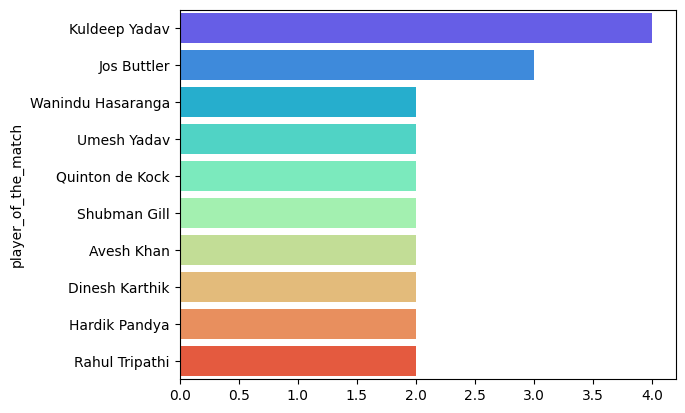

In [ ]:
sns.barplot(x=count.values,y=count.index,palette='rainbow')

<Axes: xlabel='top_scorer', ylabel='count'>

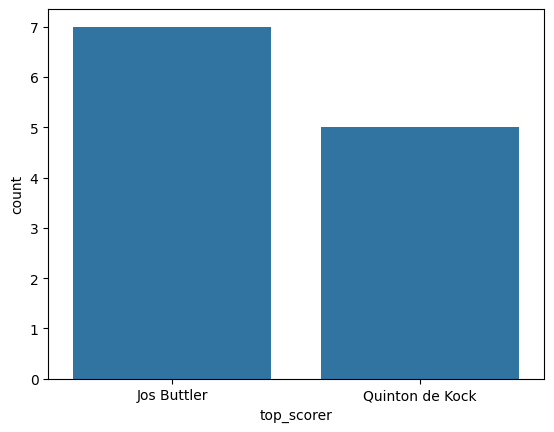

In [ ]:
#Top 2 Scorers
count=df['top_scorer'].value_counts().head(2)
count
sns.barplot(count)

<Axes: ylabel='best_bowling'>

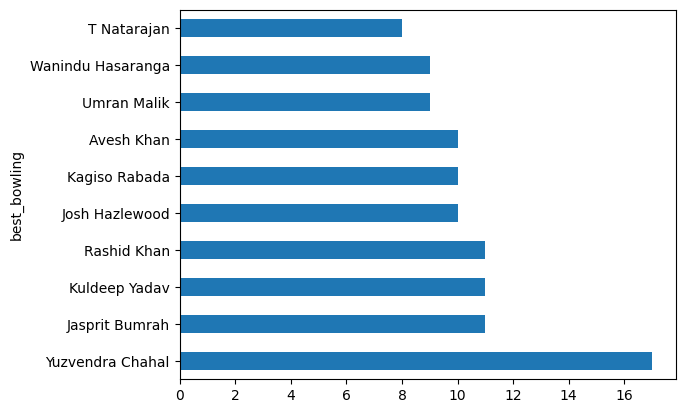

In [ ]:
#10 Best Bowling Figures
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int) # Assign the converted column back to the DataFrame
top_bowlers=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind='barh')

In [ ]:
#Most matches played at Venue
counts=df['venue'].value_counts()
counts


,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


<Axes: ylabel='venue'>

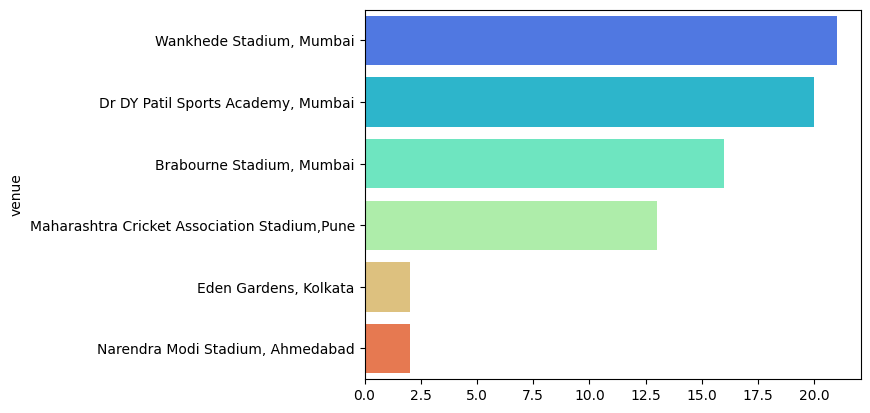

In [ ]:
sns.barplot(y=counts.index,x=counts.values,palette='rainbow')

In [ ]:
#Who won the highest margin by runs
won=df[df['won_by']=='Runs']
won.sort_values(by='margin',ascending=False).head(1)[['margin','match_winner']]

,margin,match_winner
54,91,Chennai


In [ ]:
#Who has the highest individual score
df[df['highscore']==df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
0,MS Dhoni,140.0


In [ ]:
#Which Bowler had the best bowling figure
df[df['best_bowling_figure']==df['best_bowling_figure'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
